# Always-steering: p8s + NQ-Swap + ConFiQA-QA

**실제 QA 성능은 미측정입니다.** 이 노트북 하나만 Drive에 올려 실행할 수 있습니다.

- **주 방법 A0:** rho=.06, L14–18, 모든 비패딩 prefill 토큰 + decode, 모든 입력에 적용.
- **보조 CTX:** p8s의 평균[공식 closed-book hidden − 문맥 hidden]으로 재구성. 팀원 E15의 정확한 재현 파일은 아닙니다.
- **평가:** EM/F1, C±/K×C, paired 95% CI, C+ 비열등, 회복/손상, 실측 시간·처리량·GPU 메모리.
- **외부:** NQ-Swap corpus 치환 + ConFiQA-QA. 원래 문맥과 변조 문맥 모두 **original factual answer**로 채점합니다. 원 benchmark의 문맥 충실도 점수와 직접 비교하지 않습니다.
- 각 외부 데이터 최대 1,200질문을 성능과 무관한 고정 hash로 선정. p8s/데이터 간 exact 질문 중복 제거.
- 외부 데이터에서 방향·강도·레이어를 다시 고르지 않습니다. p8s는 개발셋입니다.

**실행:** A100 GPU 권장 → 설치 → 런타임 재시작 → 경로 설정 → 토큰 → 코드 정의 → 실행.
전체 실행 시간은 미측정이며 calibration과 여러 arm의 생성이 포함됩니다. 기존 P9는 읽기만 합니다.


In [1]:
%pip install -q "transformers==5.17.0" "accelerate==1.14.0" numpy pandas pyarrow matplotlib requests huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 7.9 MB/s eta 0:00:00


설치 후 **런타임 → 세션 다시 시작**을 실행하세요. 아래 셀부터 순서대로 실행합니다.


In [4]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

# 노트북을 업로드한 실제 Drive 폴더를 지정하세요. 자동으로 /content에 저장하지 않습니다.
PROJECT_DIR = Path('/content/drive/MyDrive/12주차_실험_다영')
P9 = Path('/content/drive/MyDrive/11주차_A축_실험_다영/P9')
NOTEBOOK_NAME = 'Always_Steering_External_Eval.ipynb'
assert (PROJECT_DIR / NOTEBOOK_NAME).is_file(), 'PROJECT_DIR을 이 노트북이 있는 폴더로 맞추세요. 파일명을 바꿨다면 NOTEBOOK_NAME도 수정하세요.'
assert P9.is_dir(), '기존 P9 경로를 확인하세요.'

# 결과를 보기 전에 고정. 주 방법을 결과에 따라 바꾸지 않습니다.
PRIMARY_ARM = 'A0'          # CTX로 연구하기로 결정했다면 실행 전에만 변경
INCLUDE_CTX = True          # 라벨 없는 방향의 보조 비교
EXTERNAL_QUESTIONS = 1200   # 각 데이터셋 최대 질문 수. 변경 시 별도 프로토콜로 기록
RUN_BENCHMARK = True

CFG = dict(project_dir=str(PROJECT_DIR), p9=str(P9), primary_arm=PRIMARY_ARM,
           include_ctx=INCLUDE_CTX, rho=0.06, external_questions=EXTERNAL_QUESTIONS,
           batch_size=8, max_total_tokens=4096, benchmark=RUN_BENCHMARK)
print('결과 저장 루트:', PROJECT_DIR / 'result')
print('설정:', CFG)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
결과 저장 루트: /content/drive/MyDrive/12주차_실험_다영/result
설정: {'project_dir': '/content/drive/MyDrive/12주차_실험_다영', 'p9': '/content/drive/MyDrive/11주차_A축_실험_다영/P9', 'primary_arm': 'A0', 'include_ctx': True, 'rho': 0.06, 'external_questions': 1200, 'batch_size': 8, 'max_total_tokens': 4096, 'benchmark': True}


In [5]:
from getpass import getpass
from huggingface_hub import login
if not os.environ.get('HF_TOKEN'):
    login(token=getpass('HF read token (비공개): ').strip(), add_to_git_credential=False)


HF read token (비공개): ··········


## 평가 코드 정의
아래 셀은 모델을 실행하지 않습니다. 다음 셀에서 실행합니다.

고정 출처:
- [NQ-Swap 공개 재구성본](https://huggingface.co/datasets/younanna/NQ-Swap), `bc50bb161aa706bdf5f2e6a8ce082ac292231bc0`
- [ConFiQA 공식 저장소](https://github.com/byronBBL/Context-DPO), `557dadeeb9f47407890a5626128ca99907770b22`

NQ-Swap은 **corpus 유형만** 사용합니다. 별칭을 바꾸는 alias 유형은 C−로 취급하지 않습니다.
원래 정답/변조 정답의 별칭이 겹치거나 문맥이 같은 행은 제외합니다. 토큰 제한 초과 시 C± 쌍 전체를 제외하고 기록합니다.


In [6]:
"""Always-steering evaluation. Embedded verbatim in the Colab notebook.
No model download/generation on import. External evaluation never fits directions.
"""
import contextlib
import datetime as dt
import hashlib
import importlib.util
import json
import os
import re
import time
import unicodedata
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd

NQ_REV = 'bc50bb161aa706bdf5f2e6a8ce082ac292231bc0'
CF_REV = '557dadeeb9f47407890a5626128ca99907770b22'
SOURCES = {
    'nqswap': f'https://huggingface.co/datasets/younanna/NQ-Swap/resolve/{NQ_REV}/data/dev-00000-of-00001.parquet',
    'confiqa_qa': f'https://raw.githubusercontent.com/byronBBL/Context-DPO/{CF_REV}/ConFiQA/ConFiQA-QA.json',
}
LAYERS = [14,15,16,17,18]
SEED = 20261004


def dump(path, obj):
    def cast(x):
        if isinstance(x, np.generic): return x.item()
        if isinstance(x, Path): return str(x)
        raise TypeError(type(x).__name__)
    Path(path).write_text(json.dumps(obj, ensure_ascii=False, indent=2, default=cast), encoding='utf-8')


def sha(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for chunk in iter(lambda:f.read(1<<20),b''): h.update(chunk)
    return h.hexdigest()


def question_key(q):
    # Conservative exact normalized text dedup; no claim of semantic/entity disjointness.
    return re.sub(r'\W+', ' ', unicodedata.normalize('NFKC',str(q)).casefold()).strip()


def norm(text):
    import string
    s=unicodedata.normalize('NFKC',str(text)).lower()
    s=''.join(c for c in s if c not in string.punctuation)
    return ' '.join(w for w in s.split() if w not in {'a','an','the'})


def answers(value):
    if isinstance(value,str): value=[value]
    if isinstance(value,np.ndarray): value=value.tolist()
    if not isinstance(value,(list,tuple)): raise ValueError(f'Answer field must be string/list, got {type(value)}')
    if any(not isinstance(x,str) for x in value): raise ValueError('Nested/non-string answer field')
    result=list(dict.fromkeys(x.strip() for x in value if norm(x)))
    if not result: raise ValueError('Empty gold answers')
    return result


def truncate(raw):
    s=str(raw).strip().split('\n')[0].strip()
    s=re.sub(r'^(answer|the answer is)\s*:?\s*','',s,flags=re.I)
    abbr=r'(?<!\bDr)(?<!\bMr)(?<!\bMs)(?<!\bMrs)(?<!\bSt)(?<!\bJr)(?<!\bSr)(?<!\b[A-Z])'
    if len(s.split())>8: s=re.split(abbr+r'\.\s+(?=[A-Z])',s)[0]
    return re.sub(r'[.,;:\s]+$','',s.strip().strip('\"\'')).strip()


def token_f1(pred,gold):
    p,g=norm(pred).split(),norm(gold).split()
    if not p or not g: return float(p==g)
    common=sum((Counter(p)&Counter(g)).values())
    return 2.*common/(len(p)+len(g))


def score(pred,golds):
    golds=answers(golds)
    return int(any(norm(pred)==norm(g) for g in golds)), max(token_f1(pred,g) for g in golds)


def bootstrap(questions, delta, repeats=4000, seed=SEED):
    # Cluster by question: C+ and C- remain paired. Returns None for empty K/C cells.
    d=pd.DataFrame({'q':questions,'d':delta}).groupby('q').d.agg(['sum','count'])
    if not len(d): return dict(delta=None,lo=None,hi=None,n_questions=0)
    rng=np.random.default_rng(seed); draws=[]
    for start in range(0,repeats,100):
        ix=rng.integers(0,len(d),size=(min(100,repeats-start),len(d)))
        draws.extend((d['sum'].values[ix].sum(1)/d['count'].values[ix].sum(1)).tolist())
    lo,hi=np.percentile(draws,[2.5,97.5])
    return dict(delta=float(np.mean(delta)),lo=float(lo),hi=float(hi),n_questions=len(d))


def prop_direction(x,props,ret,acc,train,min_n=3):
    ds=[]
    for p in sorted(set(props[train])):
        a=train & ret & (props==p); b=train & acc & (props==p)
        if a.sum()>=min_n and b.sum()>=min_n: ds.append(x[a].mean(0)-x[b].mean(0))
    if not ds: raise ValueError('No property has enough retain/accept training samples')
    return unit(np.mean(ds,axis=0))


def unit(x):
    x=np.asarray(x,dtype=np.float64); n=np.linalg.norm(x,axis=-1,keepdims=True)
    if not np.isfinite(x).all() or (n<1e-8).any(): raise ValueError('Invalid direction')
    return (x/n).astype(np.float32)


def adapt_records(data,name):
    """Paired real-world-factuality task, NOT the original context-faithfulness leaderboard."""
    records=[]; exclusions=[]
    for i,r in enumerate(data):
        try:
            if name=='nqswap':
                if r.get('substitution_type')!='corpus': raise ValueError('Protocol: corpus substitutions only')
                q=r['question']; cp=r['original_context']; cm=r['substituted_context']
                gold=answers(r['original_answers']); false=answers(r['substituted_answers'])
            elif name=='confiqa_qa':
                q=r['question']; cp=r['orig_context']; cm=r['cf_context']
                gold=answers([r['orig_answer']]+list(r.get('orig_alias') or []))
                false=answers([r['cf_answer']]+list(r.get('cf_alias') or []))
            else: raise ValueError(name)
            if not all(isinstance(v,str) and v.strip() for v in [q,cp,cm]): raise ValueError('Empty text')
            if cp==cm: raise ValueError('Identical C+/C- context')
            if {norm(x) for x in gold}&{norm(x) for x in false}: raise ValueError('Gold/counterfactual alias overlap')
            key=question_key(q)
            if not key: raise ValueError('Empty question')
            records.append(dict(dataset=name,source_index=i,question=q,qkey=key,
                                cp=cp,cm=cm,gold=gold,counterfactual=false))
        except (KeyError,ValueError,TypeError) as e:
            exclusions.append(dict(dataset=name,source_index=i,reason=str(e)))
    if not records: raise ValueError(f'{name}: no records; check source schema')
    return records,exclusions


def select_pairs(records,excluded_keys,limit,seed=SEED):
    # Hash order independent of correctness, K labels, model outputs, and row sorting.
    ordered=sorted(records,key=lambda r:hashlib.sha256(f'{seed}:{r["qkey"]}:{r["source_index"]}'.encode()).hexdigest())
    seen=set(excluded_keys); selected=[]; log=[]
    for r in ordered:
        if r['qkey'] in seen:
            log.append(dict(dataset=r['dataset'],source_index=r['source_index'],reason='question overlap/duplicate'))
            continue
        seen.add(r['qkey'])
        if limit and len(selected)>=limit:
            log.append(dict(dataset=r['dataset'],source_index=r['source_index'],reason='predefined sample limit'))
            continue
        selected.append(r)
    return selected,log


def pair_rows(records):
    out=[]
    for r in records:
        for c in ['C+','C-']:
            out.append(dict(dataset=r['dataset'],qid=r['dataset']+':'+r['qkey'],question=r['question'],
                qkey=r['qkey'],C=c,context=r['cp' if c=='C+' else 'cm'],gold=r['gold'],
                context_answers=r['gold'] if c=='C+' else r['counterfactual'],source_index=r['source_index']))
    return pd.DataFrame(out)


class AlwaysHook:
    """All non-padding prefill tokens + decode; no C/K labels read at runtime."""
    def __init__(self,model,vectors,scales,attention_mask,strength=1.):
        self.model=model;self.vectors=vectors;self.scales=scales
        self.mask=attention_mask;self.strength=strength;self.handles=[];self.calls=Counter()
    def __enter__(self):
        try:
            for l in self.vectors:
                self.handles.append(self.model.model.layers[l].register_forward_hook(self.hook(l)))
        except BaseException:
            self.__exit__(None,None,None);raise
        return self
    def hook(self,l):
        def apply(mod,args,out):
            import torch
            self.calls[l]+=1
            if self.strength==0:return out
            h=out[0] if isinstance(out,(tuple,list)) else out
            v=torch.as_tensor(self.vectors[l],device=h.device,dtype=h.dtype)
            d=(self.scales[l]*self.strength*v).to(h.dtype)
            if h.shape[1]>1:
                if h.shape[:2]!=self.mask.shape:raise ValueError('Prefill mask mismatch')
                h+=self.mask.to(h.device,h.dtype)[:,:,None]*d
            else:h[:,-1,:]+=d
            return out
        return apply
    def __exit__(self,*args):
        for h in self.handles:h.remove()
        self.handles.clear()


class Runner:
    def __init__(self,model,tok,pp,max_tokens=192):
        self.model=model;self.tok=tok;self.pp=pp;self.max_tokens=max_tokens
        self.eos=sorted({tok.eos_token_id,tok.convert_tokens_to_ids('<|eot_id|>')}-{None})
    def prompt(self,q,context=None):
        msgs=self.pp.build_messages_cb(q) if context is None else self.pp.build_messages(q,context)
        return self.tok.apply_chat_template(msgs,tokenize=False,add_generation_prompt=True)
    def capture(self,prompt):
        import torch
        values={};hs=[]
        def hook(l):
            def f(m,a,o):
                x=o[0] if isinstance(o,(tuple,list)) else o
                values[l]=x[0,-1].detach().float().cpu().numpy().copy()
            return f
        try:
            for l in LAYERS:hs.append(self.model.model.layers[l].register_forward_hook(hook(l)))
            enc=self.tok(prompt,return_tensors='pt',add_special_tokens=False).to(self.model.device)
            with torch.inference_mode():self.model.model(**enc,use_cache=False,return_dict=True)
            return np.stack([values[l] for l in LAYERS])
        finally:
            for h in hs:h.remove()
    def batch(self,prompts,vectors=None,scales=None,zero=False):
        import torch
        torch.cuda.synchronize();start=time.perf_counter();torch.cuda.reset_peak_memory_stats()
        enc=self.tok(prompts,return_tensors='pt',padding=True,add_special_tokens=False).to(self.model.device)
        counter={'n':0}
        def count(m,a):counter['n']+=1
        handle=self.model.register_forward_pre_hook(count)
        edit=AlwaysHook(self.model,vectors,scales,enc.attention_mask,0. if zero else 1.) if vectors is not None else contextlib.nullcontext()
        try:
            with edit,torch.inference_mode():
                g=self.model.generate(**enc,max_new_tokens=self.max_tokens,do_sample=False,num_beams=1,
                    use_cache=True,pad_token_id=self.tok.pad_token_id,eos_token_id=self.eos)[:,enc.input_ids.shape[1]:]
            if counter['n']!=g.shape[1]:raise RuntimeError('Unexpected extra forward/generation backend')
        finally:handle.remove()
        torch.cuda.synchronize();elapsed=time.perf_counter()-start
        result=[]
        for row in g.cpu().tolist():
            stop=next((i for i,t in enumerate(row) if t in self.eos),None)
            n=len(row) if stop is None else stop
            raw=self.tok.decode(row[:n],skip_special_tokens=True,clean_up_tokenization_spaces=False)
            result.append(dict(raw=raw,n_tokens=n,hit_limit=int(stop is None and n>=self.max_tokens)))
        return result,dict(seconds=elapsed,rows=len(prompts),forward_calls=counter['n'],
            generated_tokens=sum(x['n_tokens'] for x in result),peak_bytes=torch.cuda.max_memory_allocated())
    def generate(self,frame,path,vectors=None,scales=None,batch_size=8,zero=False):
        result=[];audits=[]
        # Hash tie break, never sort by C label.
        order=frame.assign(tie=frame.rid.map(lambda r:hashlib.sha256(f'{SEED}:{r}'.encode()).hexdigest())).sort_values(['length','tie']).index.tolist()
        for start in range(0,len(order),batch_size):
            ids=order[start:start+batch_size]
            outs,audit=self.batch(frame.loc[ids,'prompt'].tolist(),vectors,scales,zero)
            result.extend(dict(rid=int(frame.loc[i,'rid']),**o) for i,o in zip(ids,outs))
            audits.append(audit)
            if path is not None:pd.DataFrame(result).to_parquet(path.with_suffix('.partial.parquet'),index=False)
            if start%(batch_size*20)==0:print('generate',str(path.name if path else 'check'),start,'/',len(order),flush=True)
        d=pd.DataFrame(result).sort_values('rid').reset_index(drop=True)
        if path is not None:
            d.to_parquet(path,index=False);dump(path.with_suffix('.audit.json'),audits)
        return d


def freeze_directions(runner,m,labels,H,saved,run,rho,include_ctx=True):
    """p8s-only fitting. ctx: official CB vs contextual prompt reconstruction, not team exact replication."""
    folds=m.fold.to_numpy();is_cm=m.C.eq('C-').to_numpy()
    props=labels.prop.to_numpy();ret=labels.ret_x.eq(1).to_numpy();acc=labels.acc_x.eq(1).to_numpy()
    if (ret&acc).any():raise ValueError('retain/accept overlap')
    x=np.stack([np.asarray(H[:,l],dtype=np.float32) for l in LAYERS],axis=1)
    # [n rows, 5 layers, hidden], only p8s activations, never external data.
    if include_ctx:
        cb={};ctx=np.empty_like(x)
        for i,row in m.iterrows():
            if row.question not in cb:cb[row.question]=runner.capture(runner.prompt(row.question))
            ctx[i]=runner.capture(row.prompt)
            if i%100==0:print('p8s calibration',i,'/',len(m),flush=True)
        diff=np.stack([cb[q] for q in m.question])-ctx
        np.savez_compressed(run/'p8s_ctx_calibration.npz',difference=diff)
    vectors={};scales={};cosines=[];manifest={}
    for fold in list(range(5))+['full']:
        train=np.ones(len(m),bool) if fold=='full' else folds!=fold
        train_questions=set(m.question[train]);test_questions=set() if fold=='full' else set(m.question[~train])
        if train_questions&test_questions:raise ValueError('Fold leakage')
        manifest[str(fold)]=dict(train_questions=sorted(train_questions),test_questions=sorted(test_questions))
        vectors[fold]={'A0':{}};scales[fold]={l:rho*float(np.median(np.linalg.norm(x[train,j],axis=1))) for j,l in enumerate(LAYERS)}
        for j,l in enumerate(LAYERS):
            u=prop_direction(x[:,j],props,ret,acc,train&is_cm)
            if fold!='full':
                ref=saved[f'w_f{fold}_L{l}'].astype(np.float32)
                cosine=float(u@ref/max(np.linalg.norm(ref),1e-12))
                if cosine<.9999:raise ValueError('A0 direction reconstruction mismatch')
                u=ref  # use exact frozen original directions for p8s OOF
            vectors[fold]['A0'][l]=u
        if include_ctx:
            uc=unit(diff[train].astype(np.float64).mean(0))
            vectors[fold]['CTX']={l:uc[j] for j,l in enumerate(LAYERS)}
            for j,l in enumerate(LAYERS):cosines.append(dict(fold=str(fold),layer=l,cos_A0=float(uc[j]@unit(vectors[fold]['A0'][l]))))
        np.savez(run/f'frozen_{fold}.npz',**{f'{a}_L{l}':v for a,vs in vectors[fold].items() for l,v in vs.items()},
                 **{f'scale_L{l}':s for l,s in scales[fold].items()})
    dump(run/'direction_fit_manifest.json',manifest)
    pd.DataFrame(cosines).to_csv(run/'direction_cosines.csv',index=False)
    return vectors,scales


def evaluate_tables(frame,gens,cb):
    cb_map=cb.set_index('qid').raw.to_dict()
    all_rows=[]
    for arm,g in gens.items():
        if set(g.rid)!=set(frame.rid) or g.rid.duplicated().any():raise ValueError('Output row mismatch')
        joined=frame.merge(g,on='rid',validate='one_to_one')
        for r in joined.itertuples():
            pred=truncate(r.raw);em,f1=score(pred,r.gold);raw_em,raw_f1=score(r.raw,r.gold)
            cb_em,_=score(truncate(cb_map[r.qid]),r.gold)
            grams=Counter(tuple(pred.split()[i:i+3]) for i in range(max(0,len(pred.split())-2)))
            all_rows.append(dict(dataset=r.dataset,rid=r.rid,qid=r.qid,question=r.question,C=r.C,
                K='K+' if cb_em else 'K-',arm=arm,raw=r.raw,pred=pred,EM=em,F1=f1,raw_EM=raw_em,raw_F1=raw_f1,
                context_match=score(pred,r.context_answers)[0],n_tokens=r.n_tokens,hit_limit=r.hit_limit,
                rep3=int(bool(grams) and max(grams.values())>=3)))
    return pd.DataFrame(all_rows)


def aggregate(rows,margin=-.02):
    metrics=[];comparisons=[]
    refs=['base','A0']
    for ds,d in rows.groupby('dataset'):
        for arm,a in d.groupby('arm'):
            masks={'ALL':np.ones(len(a),bool),'C+':a.C.eq('C+'),'C-':a.C.eq('C-')}
            masks.update({k+c:(a.K.eq(k)&a.C.eq(c)) for k in ['K+','K-'] for c in ['C+','C-']})
            for group,mask in masks.items():
                z=a.loc[mask]
                metrics.append(dict(dataset=ds,arm=arm,group=group,n=len(z),n_questions=z.qid.nunique(),
                    **{f:float(z[f].mean()) if len(z) else None for f in ['EM','F1','raw_EM','raw_F1','context_match','hit_limit','rep3']}))
                for ref in refs:
                    if arm==ref or ref not in set(d.arm):continue
                    refrows=d[d.arm==ref][['rid','EM','F1']]
                    both=z.merge(refrows,on='rid',suffixes=('','_ref'),validate='one_to_one')
                    for metric in ['EM','F1']:
                        ci=bootstrap(both.qid,both[metric]-both[metric+'_ref'])
                        comparisons.append(dict(dataset=ds,arm=arm,reference=ref,group=group,metric=metric,**ci,
                            recovery=int(((both.EM==1)&(both.EM_ref==0)).sum()),
                            damage=int(((both.EM==0)&(both.EM_ref==1)).sum()),
                            Cplus_noninferior=bool(ci['lo'] is not None and ci['lo']>=margin) if group=='C+' and metric=='EM' else None))
    return pd.DataFrame(metrics),pd.DataFrame(comparisons)


def plots(run,metrics,comparisons):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    for ds,d in metrics.groupby('dataset'):
        groups=['ALL','C+','C-','K+C+','K+C-','K-C+','K-C-'];arms=list(d.arm.unique())
        fig,axes=plt.subplots(1,2,figsize=(15,5))
        for ax,metric in zip(axes,['EM','F1']):
            for j,arm in enumerate(arms):
                vals=d[d.arm==arm].set_index('group').reindex(groups)[metric].astype(float)*100
                ax.bar(np.arange(len(groups))+(j-(len(arms)-1)/2)*.23,vals,.23,label=arm)
            ax.set(xticks=np.arange(len(groups)),xticklabels=groups,ylabel=f'{metric} (%)',ylim=(0,100),title=ds)
            ax.tick_params(axis='x',rotation=30);ax.legend()
        fig.tight_layout();fig.savefig(run/f'{ds}_metrics.png',dpi=180);plt.close(fig)
        c=comparisons[(comparisons.dataset==ds)&(comparisons.reference=='base')&(comparisons.metric=='EM')]
        fig,ax=plt.subplots(figsize=(10,6));y=0
        ticks=[];labels=[]
        for _,r in c.iterrows():
            if pd.isna(r.delta):continue
            ax.hlines(y,100*r.lo,100*r.hi,color='C0');ax.plot(100*r.delta,y,'o',color='C0')
            ticks.append(y);labels.append(r.arm+' '+r.group);y+=1
        ax.axvline(0,color='gray',ls='--');ax.set(yticks=ticks,yticklabels=labels,xlabel='EM delta vs base (pp), pointwise 95% CI',title=ds)
        fig.tight_layout();fig.savefig(run/f'{ds}_delta_ci.png',dpi=180);plt.close(fig)


def benchmark(runner,frame,vectors,scales,run,repeats=3):
    """Separate bs1 latency and bs8 throughput. Fixed query subset, warmed, order alternates."""
    sample=frame.assign(bench_key=frame.qid.map(lambda x:hashlib.sha256(f'{SEED}:bench:{x}'.encode()).hexdigest())).sort_values(['bench_key','rid']).head(64)
    specs=[('base',None,None)]+[(a,v,scales) for a,v in vectors.items()]
    runner.batch(sample.prompt.iloc[:1].tolist())
    for _,v,s in specs:runner.batch(sample.prompt.iloc[:1].tolist(),v,s)
    records=[]
    for bs in [1,8]:
        for rep in range(repeats):
            order=specs if rep%2==0 else specs[::-1]
            for arm,v,s in order:
                for start in range(0,len(sample),bs):
                    out,audit=runner.batch(sample.prompt.iloc[start:start+bs].tolist(),v,s)
                    records.append(dict(dataset=frame.dataset.iloc[0],mode=f'bs{bs}',repeat=rep,arm=arm,**audit))
    raw=pd.DataFrame(records);raw.to_csv(run/f'{frame.dataset.iloc[0]}_timing_raw.csv',index=False)
    summary=[]
    for (mode,arm),g in raw.groupby(['mode','arm']):
        summary.append(dict(dataset=frame.dataset.iloc[0],mode=mode,arm=arm,ms_per_row=1000*g.seconds.sum()/g.rows.sum(),
            rows_per_second=g.rows.sum()/g.seconds.sum(),tokens_per_second=g.generated_tokens.sum()/g.seconds.sum(),
            mean_output_tokens=g.generated_tokens.sum()/g.rows.sum(),peak_bytes=int(g.peak_bytes.max())))
    d=pd.DataFrame(summary)
    for mode in d['mode'].unique():
        b=float(d[(d['mode']==mode)&(d.arm=='base')].ms_per_row.iloc[0])
        d.loc[d['mode']==mode,'ratio_to_base']=d.loc[d['mode']==mode,'ms_per_row']/b
    d.to_csv(run/f'{frame.dataset.iloc[0]}_timing.csv',index=False)
    return d


def execute(cfg):
    import requests, torch, transformers, traceback
    project=Path(cfg['project_dir']).expanduser().resolve()
    if not project.is_dir(): raise FileNotFoundError('Create/upload notebook folder first: '+str(project))
    p9=Path(cfg['p9']).expanduser().resolve()
    if project==p9 or p9 in project.parents: raise ValueError('Results must be outside read-only P9')
    run=project/'result'/dt.datetime.now(dt.timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
    run.mkdir(parents=True,exist_ok=False)
    os.environ.setdefault('MPLCONFIGDIR',str(run/'plot_cache'))
    import matplotlib  # fail before GPU evaluation if absent
    dump(run/'status.json',dict(status='running'))
    try:
        _execute(cfg,run,p9)
    except BaseException:
        dump(run/'status.json',dict(status='failed',traceback=traceback.format_exc()))
        print('FAILED; retained partial outputs:',run)
        raise
    dump(run/'status.json',dict(status='complete'))
    print('Complete:',run)
    return run


def _execute(cfg,run,p9):
    import requests,torch,transformers
    if not torch.cuda.is_available():raise RuntimeError('CUDA GPU required; use Colab A100')
    if transformers.__version__!='5.17.0':raise RuntimeError('Install transformers==5.17.0, then restart runtime')
    if cfg['rho']!=.06:raise ValueError('This protocol freezes rho=.06; change only as a separately declared study')
    if cfg['primary_arm'] not in ['A0','CTX']:raise ValueError('Unknown primary arm')
    if not cfg['include_ctx'] and cfg['primary_arm']=='CTX':raise ValueError('CTX primary disabled')
    sv=p9/'steer_v3'
    required=['hidden_v2/p8s_behavior_v2.csv','hidden_v2/p8s_v2_h_out.npy','steer_v3/labels_v3.parquet',
        'steer_v3/env/row_manifest.parquet','steer_v3/env/manifest_cell1.json','steer_v3/code/p8s_prompt.py',
        'steer_v3/w_v3.npz','steer_v3/gen_v3_base.parquet','steer_v3/exp2_P9_r0.06.parquet']
    for f in required:
        if not (p9/f).is_file():raise FileNotFoundError(p9/f)
    dump(run/'input_hashes.json',{f:sha(p9/f) for f in required})
    if hashlib.md5((sv/'code/p8s_prompt.py').read_bytes()).hexdigest()!='20959a4c34203ea0866d030baf23595d':
        raise ValueError('Frozen p8s prompt module hash mismatch')
    spec=importlib.util.spec_from_file_location('frozen_p8s_prompt',sv/'code/p8s_prompt.py')
    pp=importlib.util.module_from_spec(spec);spec.loader.exec_module(pp)
    # Verify the locally defined metrics use the existing normalization contract.
    for s in ['The New-York','a Paris','  A_B  ','École']:
        if norm(s)!=pp.norm(s):raise ValueError('Normalization mismatch')
    m=pd.read_csv(p9/'hidden_v2/p8s_behavior_v2.csv');man=pd.read_parquet(sv/'env/row_manifest.parquet')
    labels=pd.read_parquet(sv/'labels_v3.parquet');H=np.load(p9/'hidden_v2/p8s_v2_h_out.npy',mmap_mode='r')
    saved=np.load(sv/'w_v3.npz',allow_pickle=False)
    if len(m)!=1224 or m.question.nunique()!=612:raise ValueError('Expected original p8s 612 questions')
    for col in ['question','ctx_label']:
        if not np.array_equal(m[col].values,man[col].values):raise ValueError('Manifest alignment: '+col)
        if not np.array_equal(m[col].values,labels[col].values):raise ValueError('Label alignment: '+col)
    if not np.array_equal(man.fold,labels.fold):raise ValueError('Fold mismatch')
    m['fold']=man.fold;m['C']=m.ctx_label;m['rid']=np.arange(len(m));m['dataset']='p8s_dev'
    m['context']=m.ctx_text;m['qkey']=m.question.map(question_key);m['qid']='p8s_dev:'+m.qkey
    if m.qkey.nunique()!=612:raise ValueError('Normalized p8s question collision')
    if not np.array_equal(labels.rid,m.rid):raise ValueError('Label rid mismatch')
    if set(m.fold)!=set(range(5)) or not m.groupby('qid').fold.nunique().eq(1).all():raise ValueError('Question split leakage')
    if not m.groupby('qid').C.apply(lambda s:sorted(s)==['C+','C-']).all():raise ValueError('C pair invalid')
    m['gold']=m.gold.map(lambda g:answers(json.loads(g) if isinstance(g,str) else g))
    m['context_answers']=m.answer_surface.map(lambda s:[str(s)] if pd.notna(s) and norm(s) else [])
    # p8s context surface is incomplete; never use it to define gold or primary metric.
    missing_surfaces=m.context_answers.map(len).eq(0)
    if missing_surfaces.any():raise ValueError('Missing p8s context answer surface: repair source explicitly')
    protocol=dict(**cfg,seed=SEED,source_versions={'nqswap':NQ_REV,'confiqa_qa':CF_REV},layers=LAYERS,
        target='original factual answer on BOTH original and substituted contexts; adapted robustness task, not original benchmark score',
        primary='preset arm vs base: ALL EM improvement AND C- EM improvement AND C+ EM noninferiority',
        margin=-.02,bootstrap='question-cluster paired, 4000 replicates, pointwise intervals',
        dataset_success='all three criteria per external dataset; broad claim requires BOTH external datasets',
        selection='deterministic hash, no selection using model performance or K labels',
        nq_substitution='corpus only; alias is not misinformation and type_swap/popularity not mixed into this protocol',
        calibration='p8s only; OOF for development, full p8s for external transfer; no external MED/direction tuning',
        ctx_definition='mean(official closed-book prompt hidden - contextual prompt hidden); all p8s C rows, no direction labels',
        ctx_caveat='system instructions differ; independently reconstructed candidate, not exact reproduction of teammate E15 w_ctx',
        K_definition='fresh unsteered closed-book exact EM, used for analysis only; separate calls excluded from deployment cost',
        p8s_status='reused development set, not confirmation even with OOF',
        timing='fixed hash-selected up to 64 rows/dataset, 3 repetitions; warmed bs1/bs8; model+tokenization, excludes CB audit and calibration, varies with generated length',
        ni_interpretation='margin is a prior project convention; acceptance does not mean zero harm',
        cross_dataset_overlap='normalized exact question removal only, not entity or semantic disjointness',
        output_parser='existing trunc_v3; also retain full raw-answer EM/F1 as sensitivity')
    dump(run/'protocol.json',protocol)  # written BEFORE any generation/outcome inspection
    rawdir=run/'source_data';rawdir.mkdir()
    external={};exclusions=[];used=set(m.qkey)
    for name,url in SOURCES.items():
        target=rawdir/('nqswap.parquet' if name=='nqswap' else 'ConFiQA-QA.json')
        response=requests.get(url,timeout=120);response.raise_for_status();target.write_bytes(response.content)
        records=pd.read_parquet(target).to_dict('records') if name=='nqswap' else json.loads(target.read_text())
        pairs,log=adapt_records(records,name);exclusions.extend(log)
        selected,log=select_pairs(pairs,used,cfg['external_questions']);exclusions.extend(log)
        if not selected:raise ValueError('No eligible external questions: '+name)
        external[name]=pair_rows(selected);used.update(r['qkey'] for r in selected)
    dump(run/'source_hashes.json',{p.name:sha(p) for p in rawdir.iterdir()})
    torch.manual_seed(SEED);np.random.seed(SEED)
    torch.use_deterministic_algorithms(True,warn_only=True)
    torch.backends.cuda.matmul.allow_tf32=False;torch.backends.cudnn.allow_tf32=False;torch.backends.cudnn.benchmark=False
    from transformers import AutoTokenizer,AutoModelForCausalLM
    revision=json.loads((sv/'env/manifest_cell1.json').read_text())['model_revision']
    tok=AutoTokenizer.from_pretrained(pp.MODEL_ID,revision=revision)
    tok.padding_side='left'
    if tok.pad_token is None:tok.pad_token=tok.eos_token
    model=AutoModelForCausalLM.from_pretrained(pp.MODEL_ID,revision=revision,dtype=torch.bfloat16,
        device_map='auto',attn_implementation='sdpa').eval()
    runner=Runner(model,tok,pp,max_tokens=pp.MAX_NEW_TOKENS)
    dump(run/'environment.json',dict(torch=torch.__version__,transformers=transformers.__version__,
        model=pp.MODEL_ID,revision=revision,gpu=torch.cuda.get_device_name(0),dtype=str(model.dtype),numpy=np.__version__,pandas=pd.__version__))
    datasets={'p8s_dev':m,**external}
    for name,frame in list(datasets.items()):
        frame=frame.copy();frame['prompt']=[runner.prompt(r.question,r.context) for r in frame.itertuples()]
        frame['length']=[len(tok(p,add_special_tokens=False).input_ids) for p in frame.prompt]
        if name=='p8s_dev':
            if not all(hashlib.md5(p.encode()).hexdigest()==h for p,h in zip(frame.prompt,man.prompt_md5)):
                raise ValueError('Original prompt hash mismatch')
        bad=set(frame.loc[frame.length+pp.MAX_NEW_TOKENS>cfg['max_total_tokens'],'qid'])
        if name=='p8s_dev' and bad:raise ValueError('p8s context length exceeds limit; do not truncate')
        for q in bad:exclusions.append(dict(dataset=name,source_index=None,reason='pair removed: max length',qid=q))
        frame=frame[~frame.qid.isin(bad)].reset_index(drop=True)
        if not len(frame):raise ValueError('All pairs exceed length budget: '+name)
        frame['rid']=np.arange(len(frame));datasets[name]=frame
        frame.to_parquet(run/f'{name}_manifest.parquet',index=False)
    pd.DataFrame(exclusions).to_csv(run/'exclusions.csv',index=False)
    dump(run/'sample_counts.json',{n:dict(rows=len(d),questions=d.qid.nunique()) for n,d in datasets.items()})
    m=datasets['p8s_dev']
    vectors,scales=freeze_directions(runner,m,labels,H,saved,run,cfg['rho'],cfg['include_ctx'])
    arms=['base','A0']+(['CTX'] if cfg['include_ctx'] else [])
    # Explicit exact no-op check before scoring any new method.
    check=m[m.fold==0].head(8)
    a,_=runner.batch(check.prompt.tolist());b,_=runner.batch(check.prompt.tolist(),vectors[0]['A0'],scales[0],zero=True)
    if [x['raw'] for x in a]!=[x['raw'] for x in b]:raise RuntimeError('Zero hook changes generation')
    dump(run/'zero_hook.json',dict(exact_match=True,n=len(check)))
    all_scores=[];timing=[]
    for name,frame in datasets.items():
        dsdir=run/name;dsdir.mkdir();gens={}
        # CB calls are evaluation-only for K partition, never used by steering/gating.
        q=frame.drop_duplicates('qid')[['qid','question','gold']].reset_index(drop=True)
        q['rid']=np.arange(len(q));q['prompt']=[runner.prompt(x) for x in q.question]
        q['length']=[len(tok(p,add_special_tokens=False).input_ids) for p in q.prompt]
        cb=runner.generate(q,dsdir/'closed_book.parquet',batch_size=cfg['batch_size'])
        cb=cb.merge(q[['rid','qid']],on='rid',validate='one_to_one')
        cb.to_parquet(dsdir/'closed_book.parquet',index=False)
        for arm in arms:
            if name=='p8s_dev':
                pieces=[]
                for fold in range(5):
                    f=frame[frame.fold==fold]
                    pieces.append(runner.generate(f,dsdir/f'{arm}_fold{fold}.parquet',
                        None if arm=='base' else vectors[fold][arm],None if arm=='base' else scales[fold],batch_size=16))
                g=pd.concat(pieces).sort_values('rid').reset_index(drop=True)
            else:
                g=runner.generate(frame,dsdir/f'{arm}.parquet',None if arm=='base' else vectors['full'][arm],
                                  None if arm=='base' else scales['full'],batch_size=cfg['batch_size'])
            g.to_parquet(dsdir/f'{arm}.parquet',index=False);gens[arm]=g
            if name=='p8s_dev' and arm in ['base','A0']:
                filename='gen_v3_base.parquet' if arm=='base' else 'exp2_P9_r0.06.parquet'
                ref=pd.read_parquet(sv/filename)
                if not np.array_equal(ref.rid,g.rid):raise ValueError('Reference rid mismatch')
                mismatches=int((ref.raw.values!=g.raw.values).sum());limit=15 if arm=='base' else 20
                dump(dsdir/f'{arm}_reproduction.json',dict(mismatches=mismatches,allowed=limit,
                    note='hash tie breaks differ from original baseline batches'))
                if mismatches>limit:raise RuntimeError('p8s reproduction failed; stop before external evaluation')
        rows=evaluate_tables(frame,gens,cb);rows.to_parquet(dsdir/'scored_rows.parquet',index=False)
        all_scores.append(rows)
        if name!='p8s_dev' and cfg['benchmark']:
            timing.append(benchmark(runner,frame,vectors['full'],scales['full'],run))
        metrics,comparisons=aggregate(pd.concat(all_scores,ignore_index=True))
        metrics.to_csv(run/'metrics.csv',index=False);comparisons.to_csv(run/'comparisons.csv',index=False)
        plots(run,metrics,comparisons)
        print(metrics[(metrics.dataset==name)&metrics.group.isin(['ALL','C+','C-'])].to_string(index=False))
    combined=pd.concat(all_scores,ignore_index=True);combined.to_parquet(run/'all_scored_rows.parquet',index=False)
    changed=[]
    for name,ds in combined.groupby('dataset'):
        base=ds[ds.arm=='base'][['rid','raw','EM']]
        for arm,a in ds.groupby('arm'):
            if arm=='base':continue
            z=a.merge(base,on='rid',suffixes=('','_base'),validate='one_to_one')
            changed.append(z[z.raw!=z.raw_base])
    pd.concat(changed).to_csv(run/'changed_rows_unblinded.csv',index=False)
    if timing:
        pd.concat(timing).to_csv(run/'timing_summary.csv',index=False)
        import matplotlib.pyplot as plt
        t=pd.concat(timing);fig,axes=plt.subplots(1,2,figsize=(11,4))
        for ax,mode in zip(axes,['bs1','bs8']):
            v=t[t['mode']==mode];ax.bar(v.dataset+' '+v.arm,v.ratio_to_base)
            ax.axhline(1,color='gray',ls='--');ax.set(title=mode,ylabel='Time per row / base');ax.tick_params(axis='x',rotation=45)
        fig.tight_layout();fig.savefig(run/'timing.png',dpi=180);plt.close(fig)
    verdict=[]
    for name in external:
        c=comparisons[(comparisons.dataset==name)&(comparisons.arm==cfg['primary_arm'])&
                      (comparisons.reference=='base')&(comparisons.metric=='EM')].set_index('group')
        flags=dict(overall_improvement=bool(c.loc['ALL','lo']>0),Cminus_improvement=bool(c.loc['C-','lo']>0),
                   Cplus_noninferiority=bool(c.loc['C+','lo']>=-.02))
        verdict.append(dict(dataset=name,**flags,all_criteria_pass=all(flags.values())))
    dump(run/'verdict.json',dict(primary_arm=cfg['primary_arm'],datasets=verdict,
        both_external_datasets_pass=all(v['all_criteria_pass'] for v in verdict),
        caveat='Pointwise bootstrap intervals; no post-hoc best-arm selection. Development selection uncertainty and pretraining contamination are not estimated.'))


In [7]:
# 같은 폴더에서 다른 런타임이 동시에 이 실행 결과를 수정하지 않도록 하세요.
# 매번 새 실행 폴더 생성. 실패 후 재실행은 자동 resume가 아니라 새 실험 실행입니다.
CFG['eval_code_sha256'] = '1e4cd9a816dbcd871edcfa326d470949d1c47b4324fc4d33b5d95b26db8d564e'
RUN = execute(CFG)


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

p8s calibration 0 / 1224
p8s calibration 100 / 1224
p8s calibration 200 / 1224
p8s calibration 300 / 1224
p8s calibration 400 / 1224
p8s calibration 500 / 1224
p8s calibration 600 / 1224
p8s calibration 700 / 1224
p8s calibration 800 / 1224
p8s calibration 900 / 1224
p8s calibration 1000 / 1224
p8s calibration 1100 / 1224
p8s calibration 1200 / 1224
generate closed_book.parquet 0 / 612
generate closed_book.parquet 160 / 612
generate closed_book.parquet 320 / 612
generate closed_book.parquet 480 / 612
generate base_fold0.parquet 0 / 246
generate base_fold1.parquet 0 / 246
generate base_fold2.parquet 0 / 244
generate base_fold3.parquet 0 / 244
generate base_fold4.parquet 0 / 244
generate A0_fold0.parquet 0 / 246
generate A0_fold1.parquet 0 / 246
generate A0_fold2.parquet 0 / 244
generate A0_fold3.parquet 0 / 244
generate A0_fold4.parquet 0 / 244
generate CTX_fold0.parquet 0 / 246
generate CTX_fold1.parquet 0 / 246
generate CTX_fold2.parquet 0 / 244
generate CTX_fold3.parquet 0 / 244
gene

## 결과 확인
EM/F1은 0~1 단위입니다. Δ에 100을 곱하면 %p입니다.
주 판정은 **미리 정한 방법 vs base**의 전체 EM 개선, C− EM 개선, C+ 비열등(−2%p)입니다.
C+ 비열등 통과는 손상 0을 뜻하지 않습니다. CI는 pointwise이고 방향 학습·방법 선택의 불확실성을 포함하지 않습니다.


실행 폴더: /content/drive/MyDrive/12주차_실험_다영/result/20261004T085540433485Z
{
  "status": "complete"
}


,dataset,arm,group,n,n_questions,EM,F1,raw_EM,raw_F1,context_match,hit_limit,rep3
0,confiqa_qa,A0,ALL,2400,1200,0.544167,0.631873,0.544167,0.631873,0.560000,0.0,0.0
1,confiqa_qa,A0,C+,1200,1200,0.779167,0.854299,0.779167,0.854299,0.779167,0.0,0.0
2,confiqa_qa,A0,C-,1200,1200,0.309167,0.409447,0.309167,0.409447,0.340833,0.0,0.0
3,confiqa_qa,A0,K+C+,497,497,0.969819,0.977465,0.969819,0.977465,0.969819,0.0,0.0
4,confiqa_qa,A0,K+C-,497,497,0.609658,0.666479,0.609658,0.666479,0.241449,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
58,p8s_dev,base,C-,612,612,0.259804,0.298790,0.259804,0.298790,0.477124,0.0,0.0
59,p8s_dev,base,K+C+,315,315,0.923810,0.943810,0.923810,0.943810,0.746032,0.0,0.0
60,p8s_dev,base,K+C-,315,315,0.450794,0.478403,0.450794,0.478403,0.387302,0.0,0.0
61,p8s_dev,base,K-C+,297,297,0.673401,0.774897,0.673401,0.774897,0.585859,0.0,0.0


,dataset,arm,reference,group,metric,delta,lo,hi,n_questions,recovery,damage,Cplus_noninferior
0,confiqa_qa,A0,base,ALL,EM,0.032917,0.021667,0.044177,1200,140,61,NaN
1,confiqa_qa,A0,base,ALL,F1,0.031711,0.021414,0.042104,1200,140,61,NaN
2,confiqa_qa,A0,base,C+,EM,-0.030000,-0.043333,-0.017500,1200,15,51,False
3,confiqa_qa,A0,base,C+,F1,-0.031016,-0.041015,-0.021394,1200,15,51,NaN
4,confiqa_qa,A0,base,C-,EM,0.095833,0.078333,0.114167,1200,125,10,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
163,p8s_dev,base,A0,K+C-,F1,-0.195508,-0.242185,-0.150366,315,2,65,NaN
164,p8s_dev,base,A0,K-C+,EM,0.003367,-0.023569,0.030303,297,9,8,NaN
165,p8s_dev,base,A0,K-C+,F1,0.009681,-0.012289,0.032577,297,9,8,NaN
166,p8s_dev,base,A0,K-C-,EM,-0.067340,-0.101010,-0.037037,297,1,21,NaN


{
  "primary_arm": "A0",
  "datasets": [
    {
      "dataset": "nqswap",
      "overall_improvement": true,
      "Cminus_improvement": true,
      "Cplus_noninferiority": false,
      "all_criteria_pass": false
    },
    {
      "dataset": "confiqa_qa",
      "overall_improvement": true,
      "Cminus_improvement": true,
      "Cplus_noninferiority": false,
      "all_criteria_pass": false
    }
  ],
  "both_external_datasets_pass": false,
  "caveat": "Pointwise bootstrap intervals; no post-hoc best-arm selection. Development selection uncertainty and pretraining contamination are not estimated."
}


,dataset,mode,arm,ms_per_row,rows_per_second,tokens_per_second,mean_output_tokens,peak_bytes,ratio_to_base
0,nqswap,bs1,A0,184.586244,5.417522,13.374507,2.468750,16262096896,0.997019
1,nqswap,bs1,CTX,187.153918,5.343196,13.441477,2.515625,16262096896,1.010888
2,nqswap,bs1,base,185.138137,5.401372,14.009809,2.593750,16262096896,1.000000
3,nqswap,bs8,A0,65.776744,15.202942,37.769808,2.484375,17399541760,1.027941
4,nqswap,bs8,CTX,63.665483,15.707098,39.513169,2.515625,17399541760,0.994947
5,nqswap,bs8,base,63.988824,15.627729,40.534422,2.593750,17399541760,1.000000
6,confiqa_qa,bs1,A0,214.699732,4.657668,14.264107,3.062500,16211519488,1.034590
7,confiqa_qa,bs1,CTX,217.630945,4.594935,14.287375,3.109375,16211519488,1.048715
8,confiqa_qa,bs1,base,207.521501,4.818778,14.531627,3.015625,16211519488,1.000000
9,confiqa_qa,bs8,A0,64.710148,15.453527,47.809348,3.093750,17035341312,1.080594


confiqa_qa_delta_ci.png


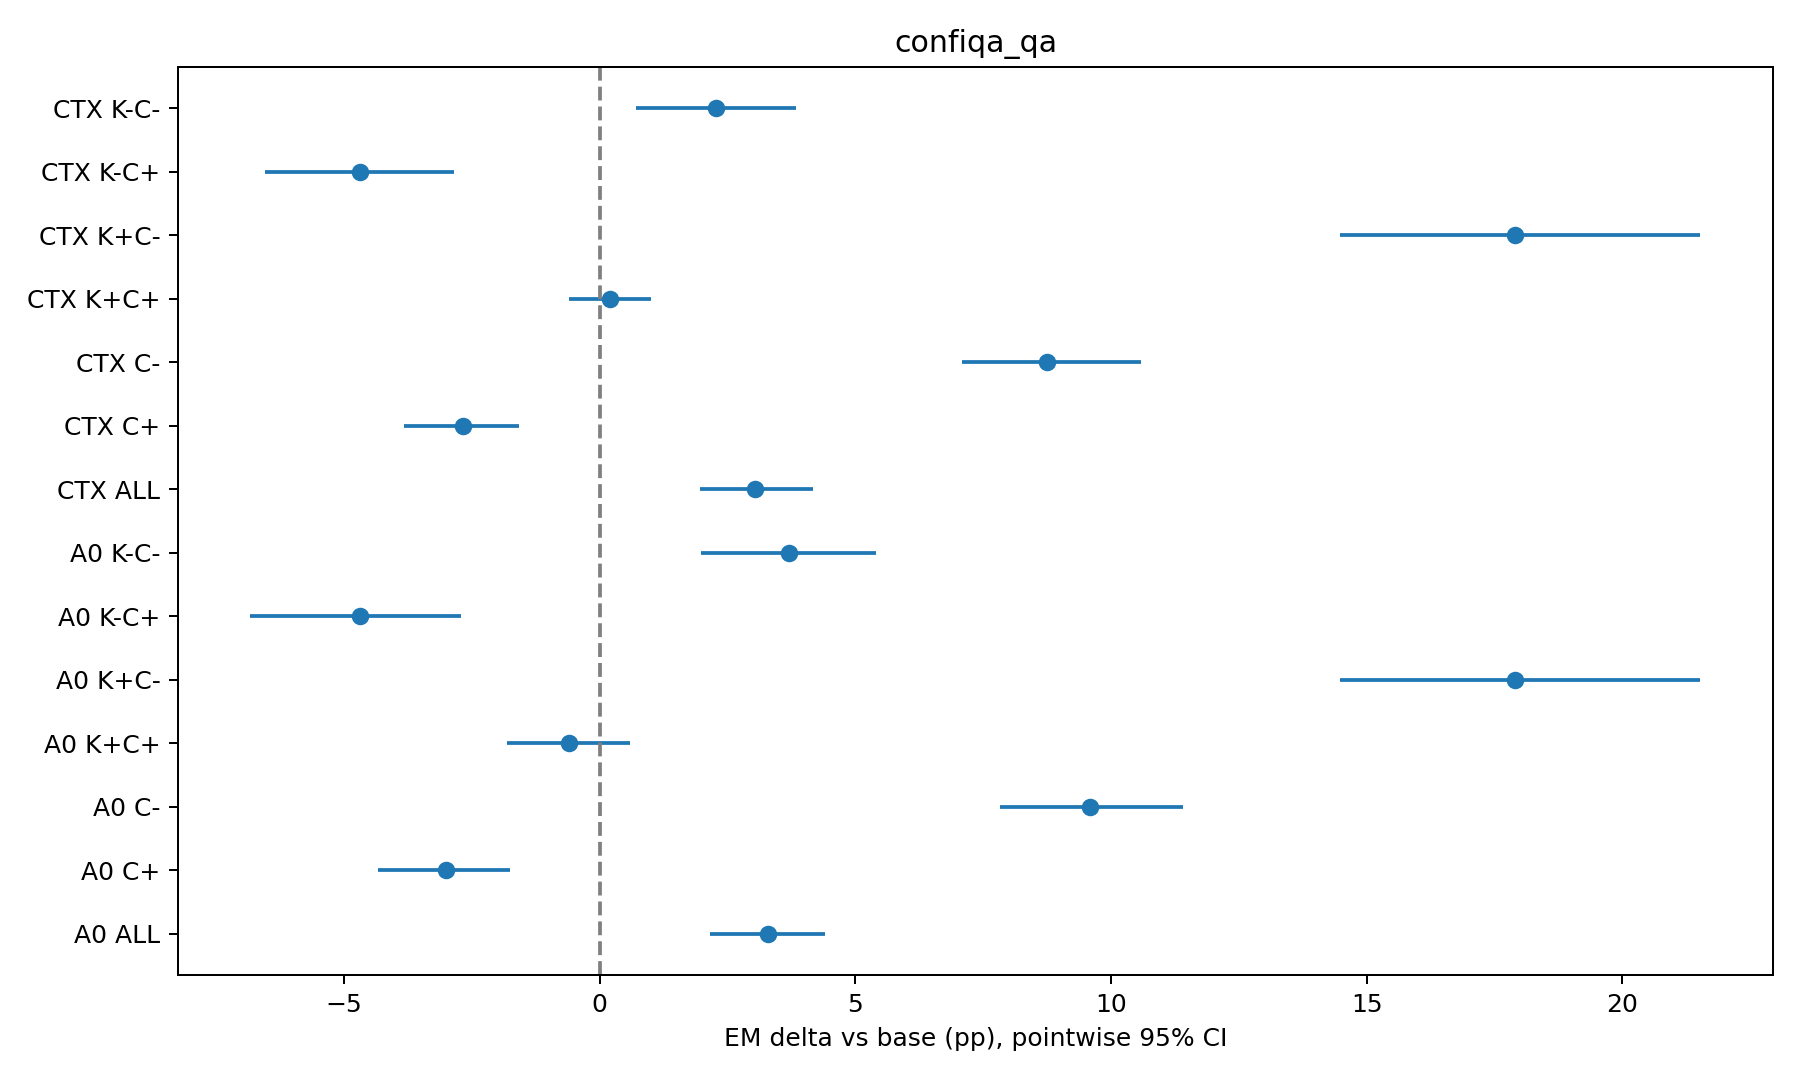

confiqa_qa_metrics.png


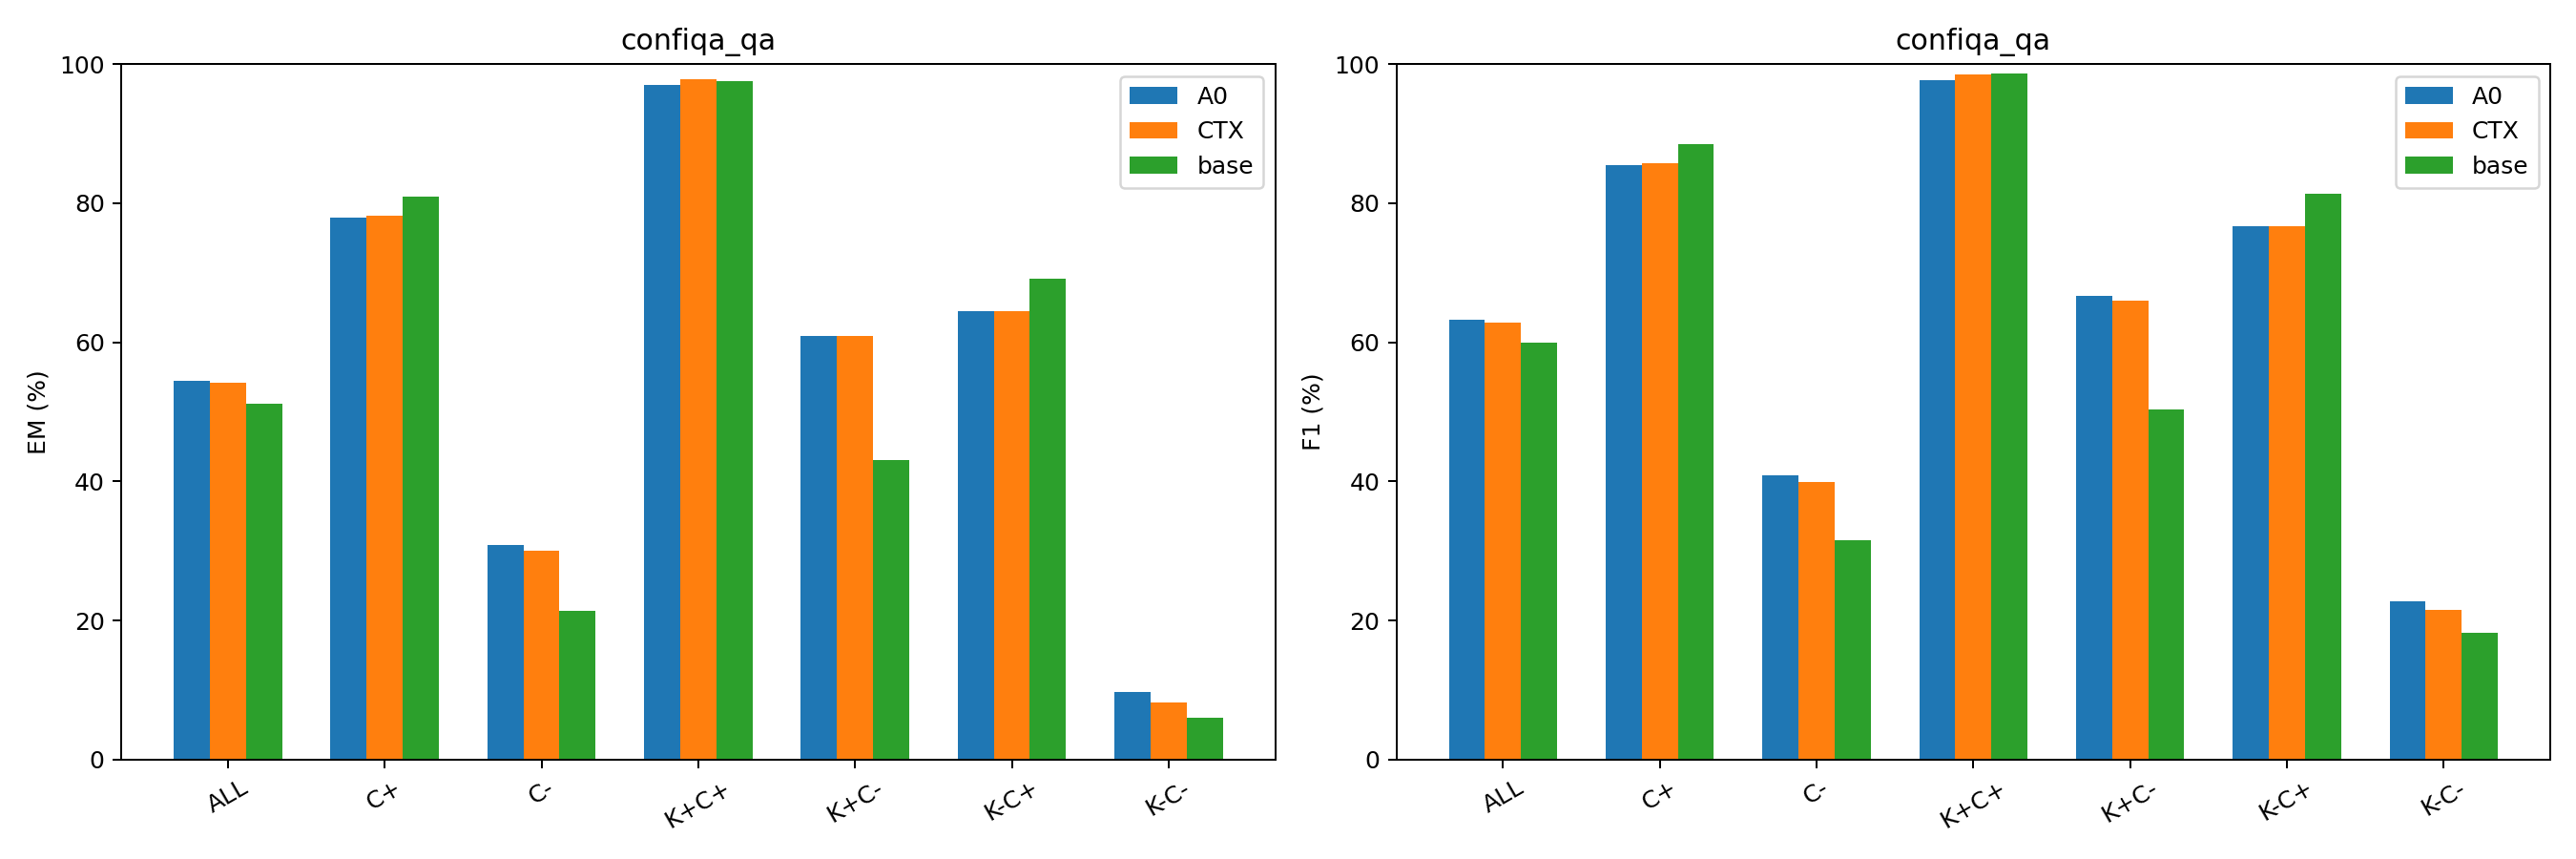

nqswap_delta_ci.png


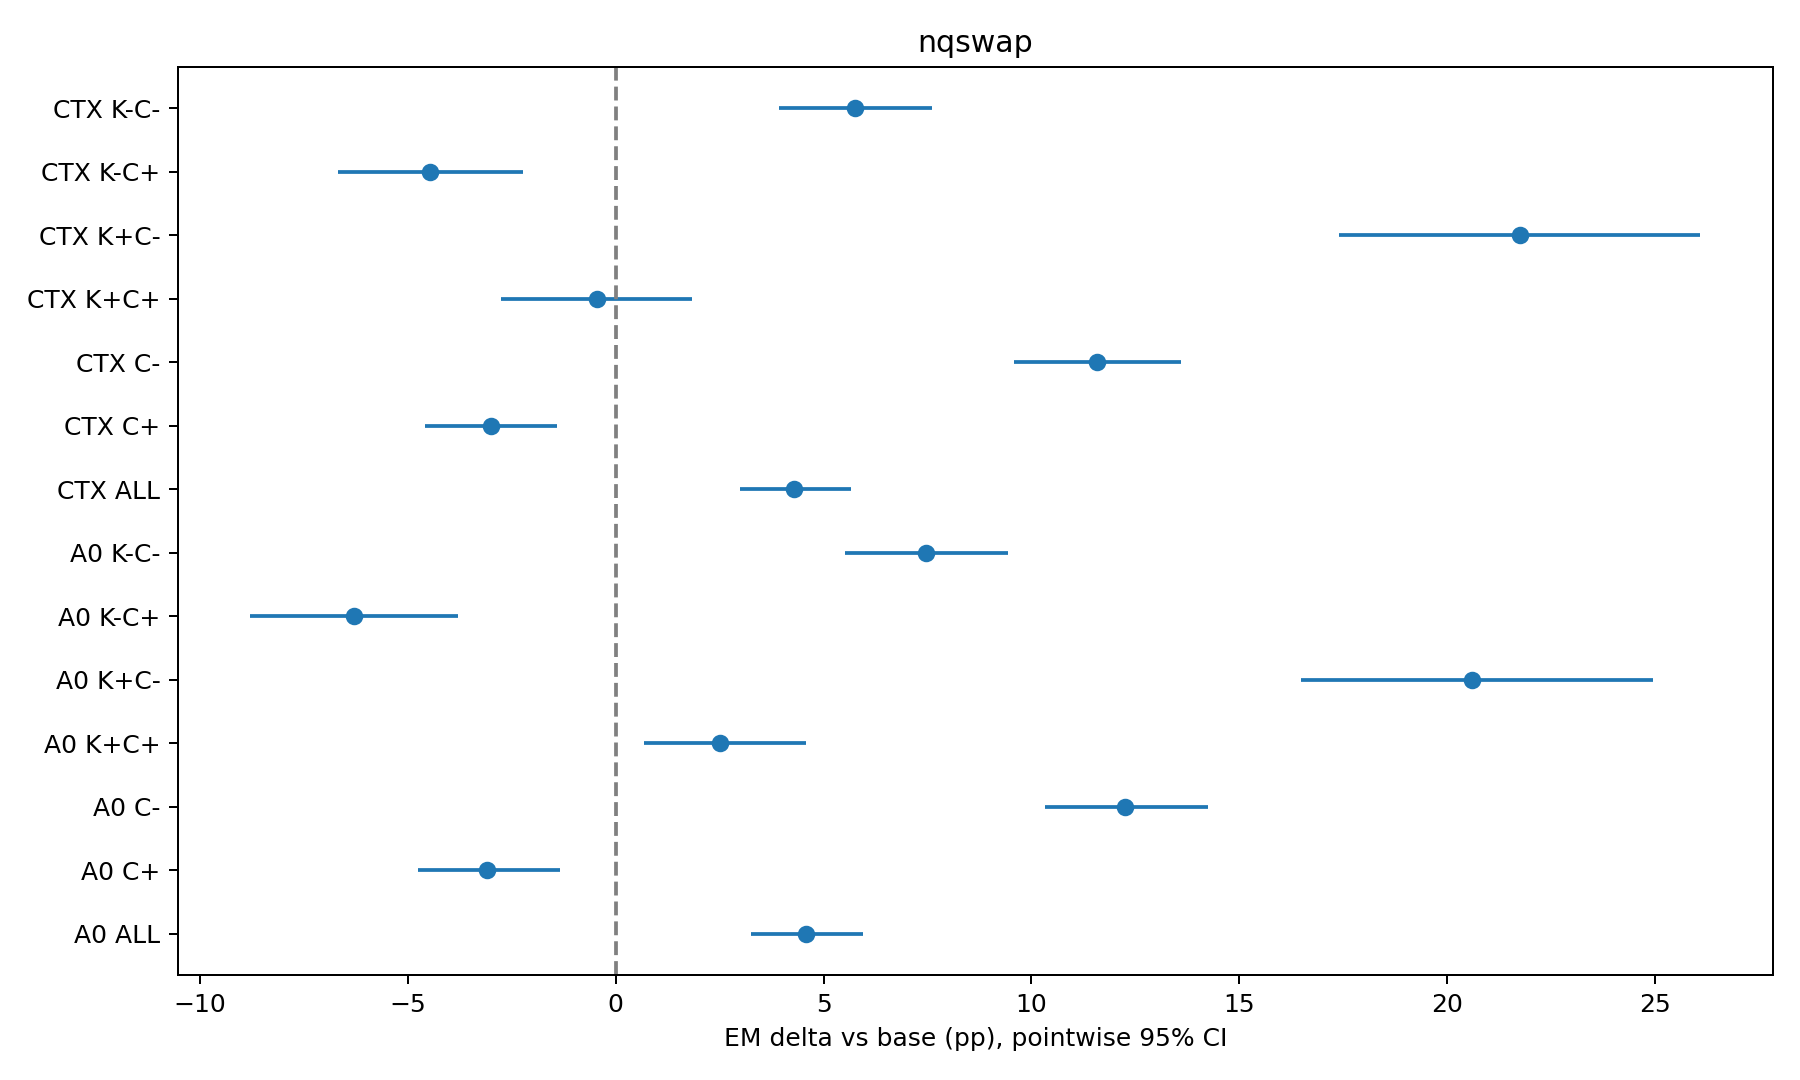

nqswap_metrics.png


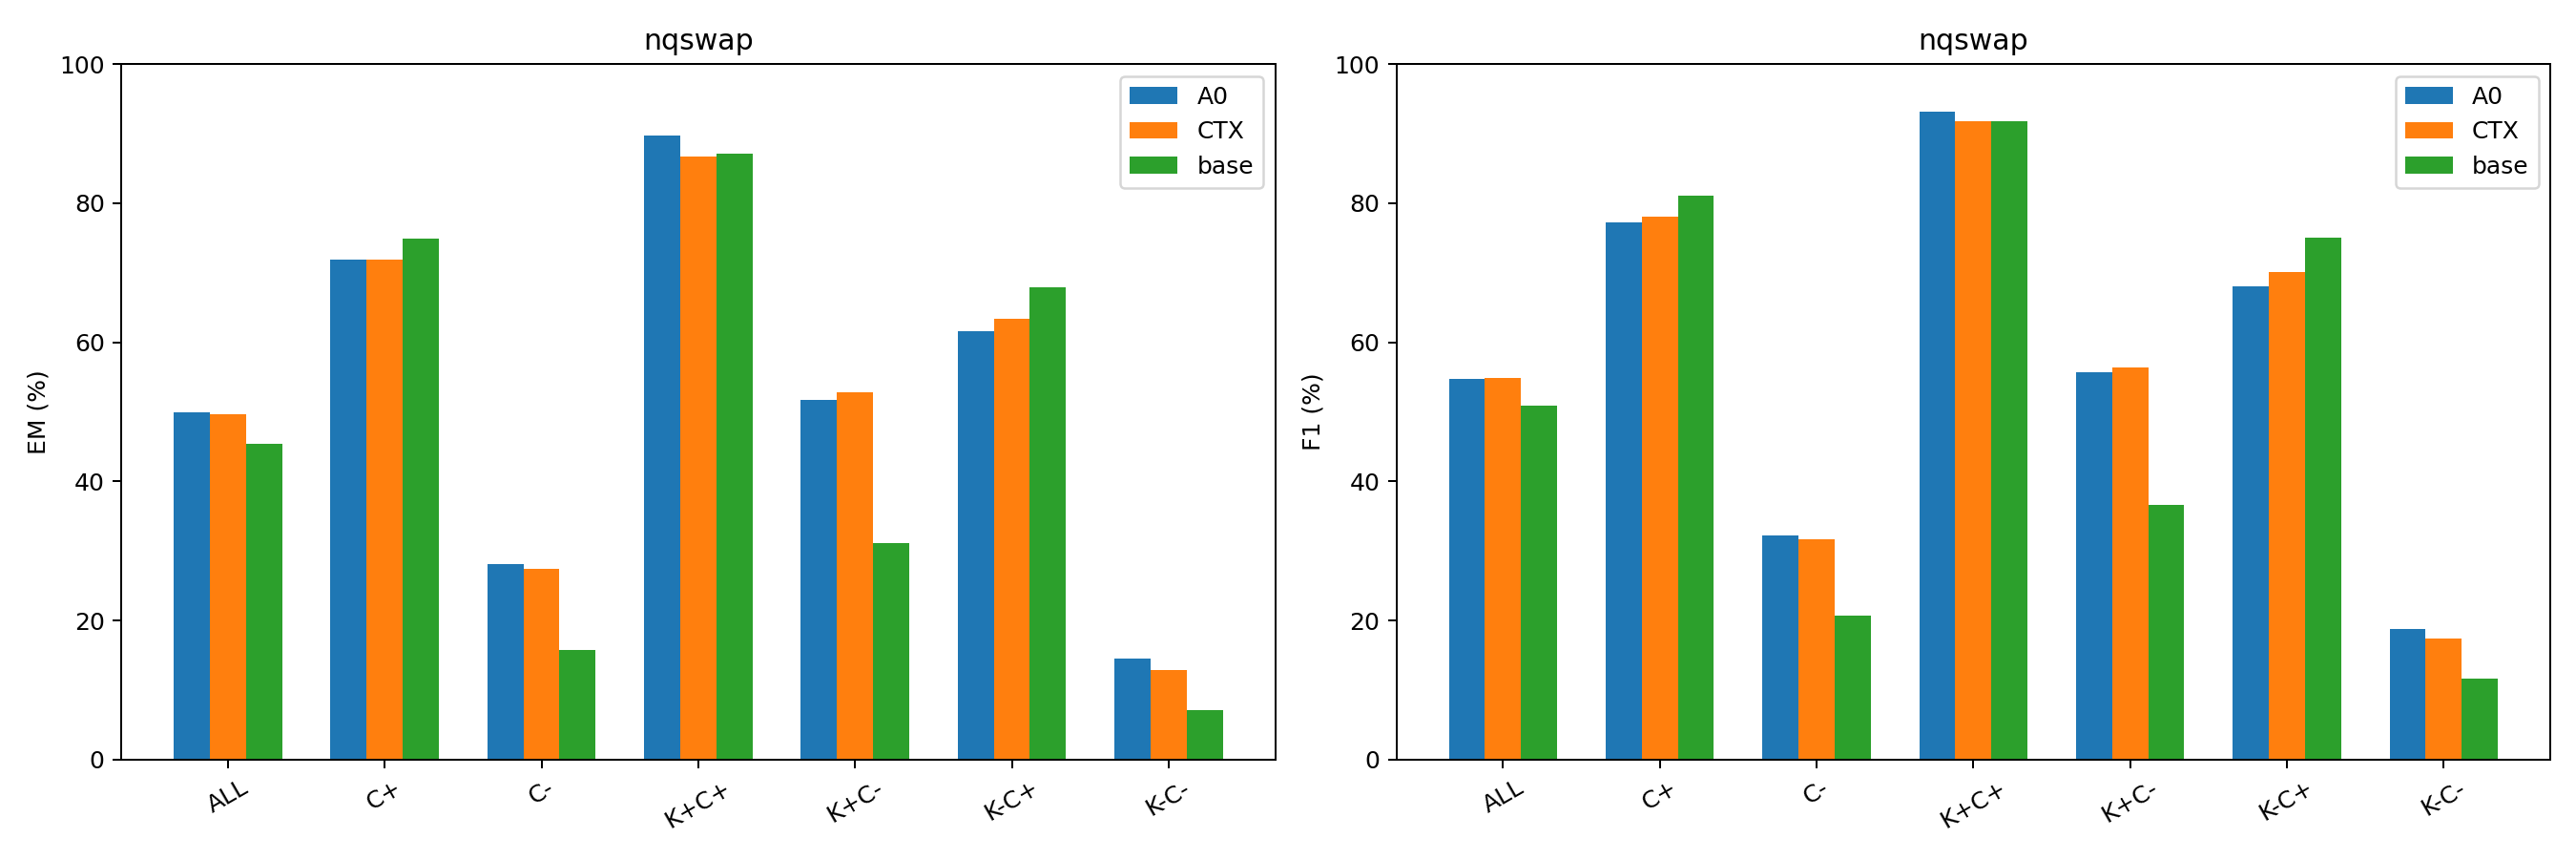

p8s_dev_delta_ci.png


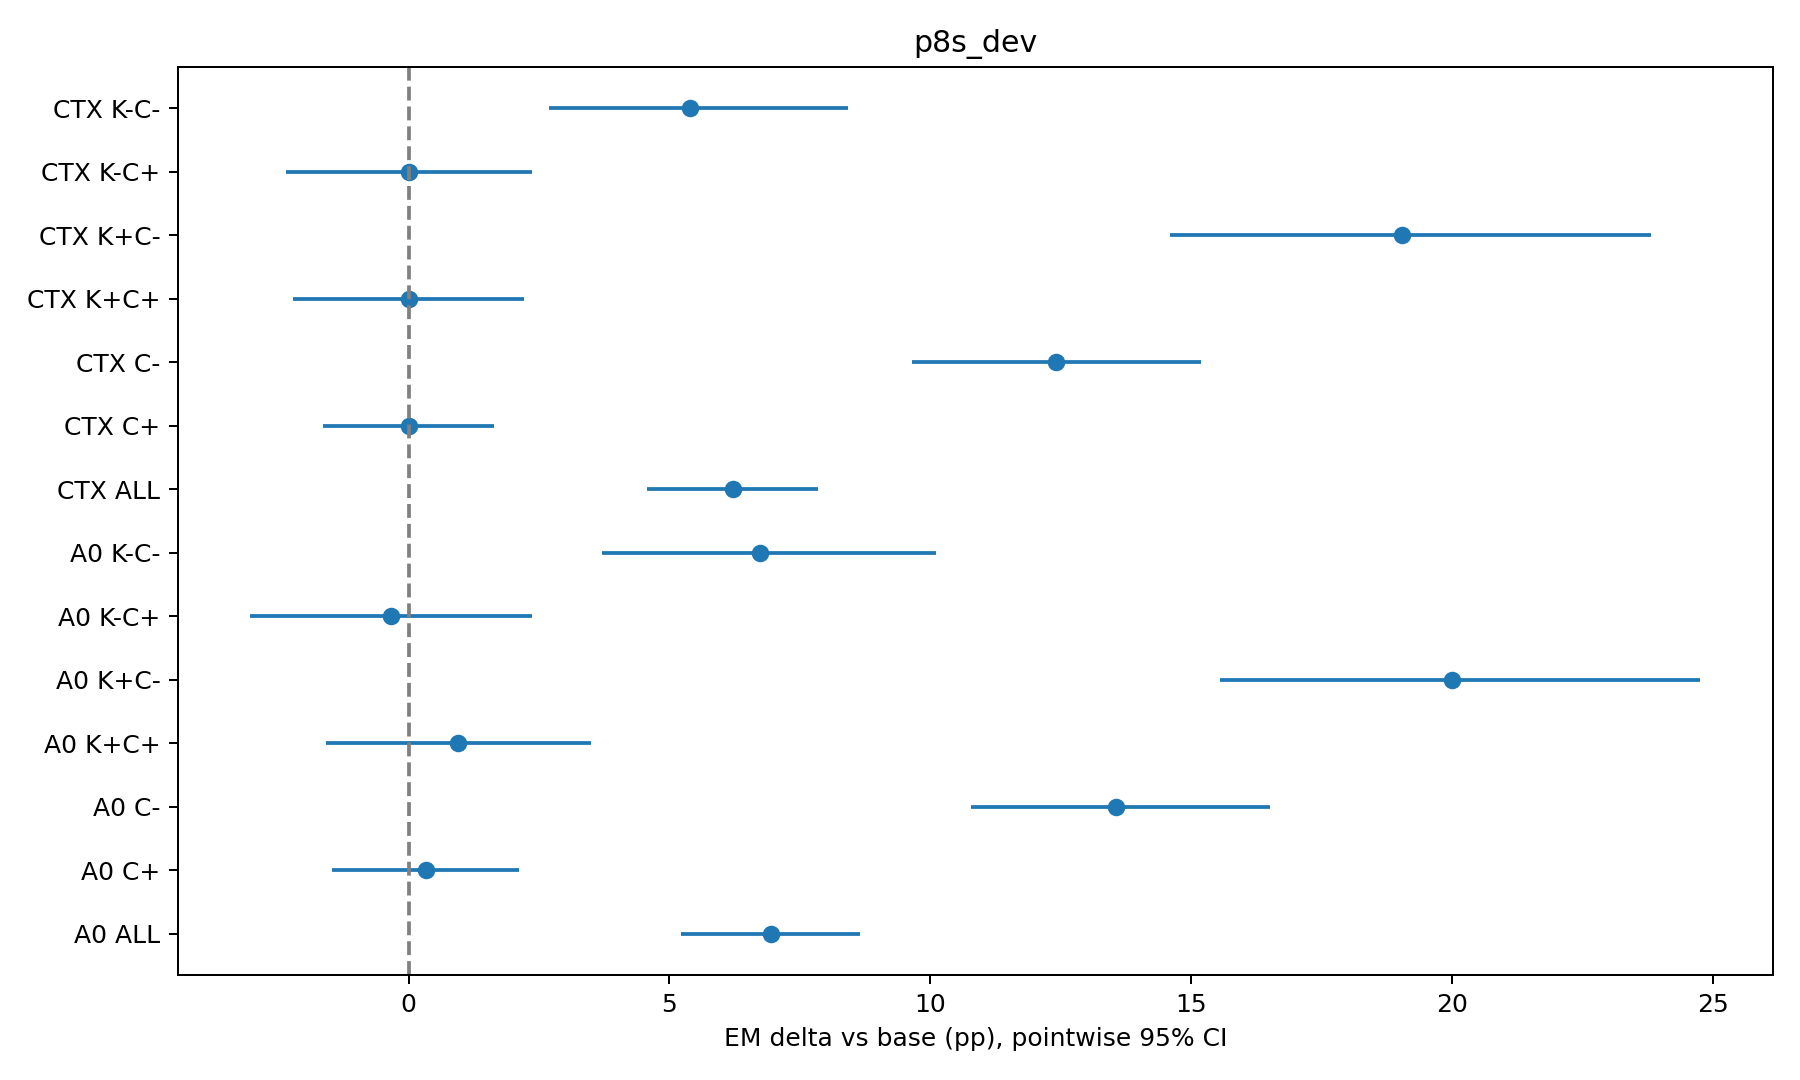

p8s_dev_metrics.png


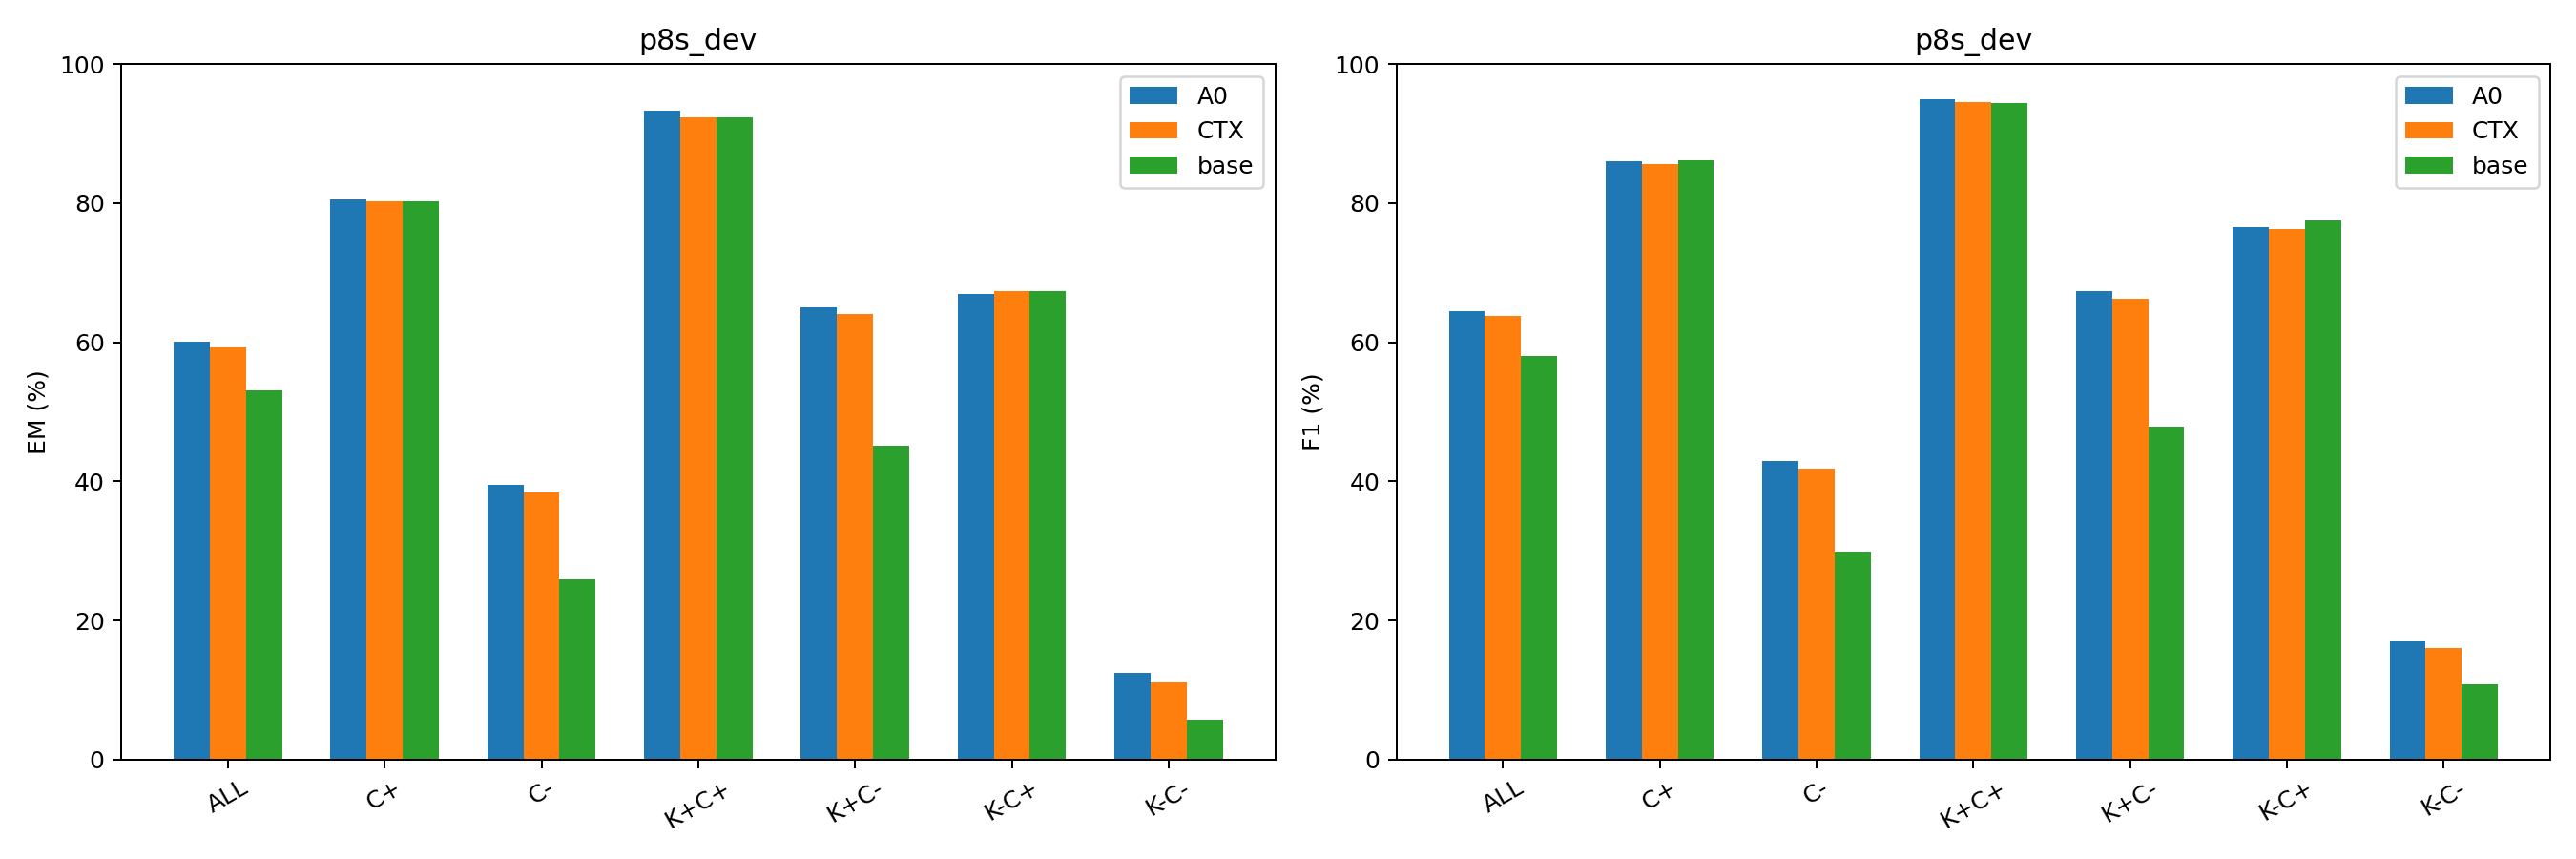

timing.png


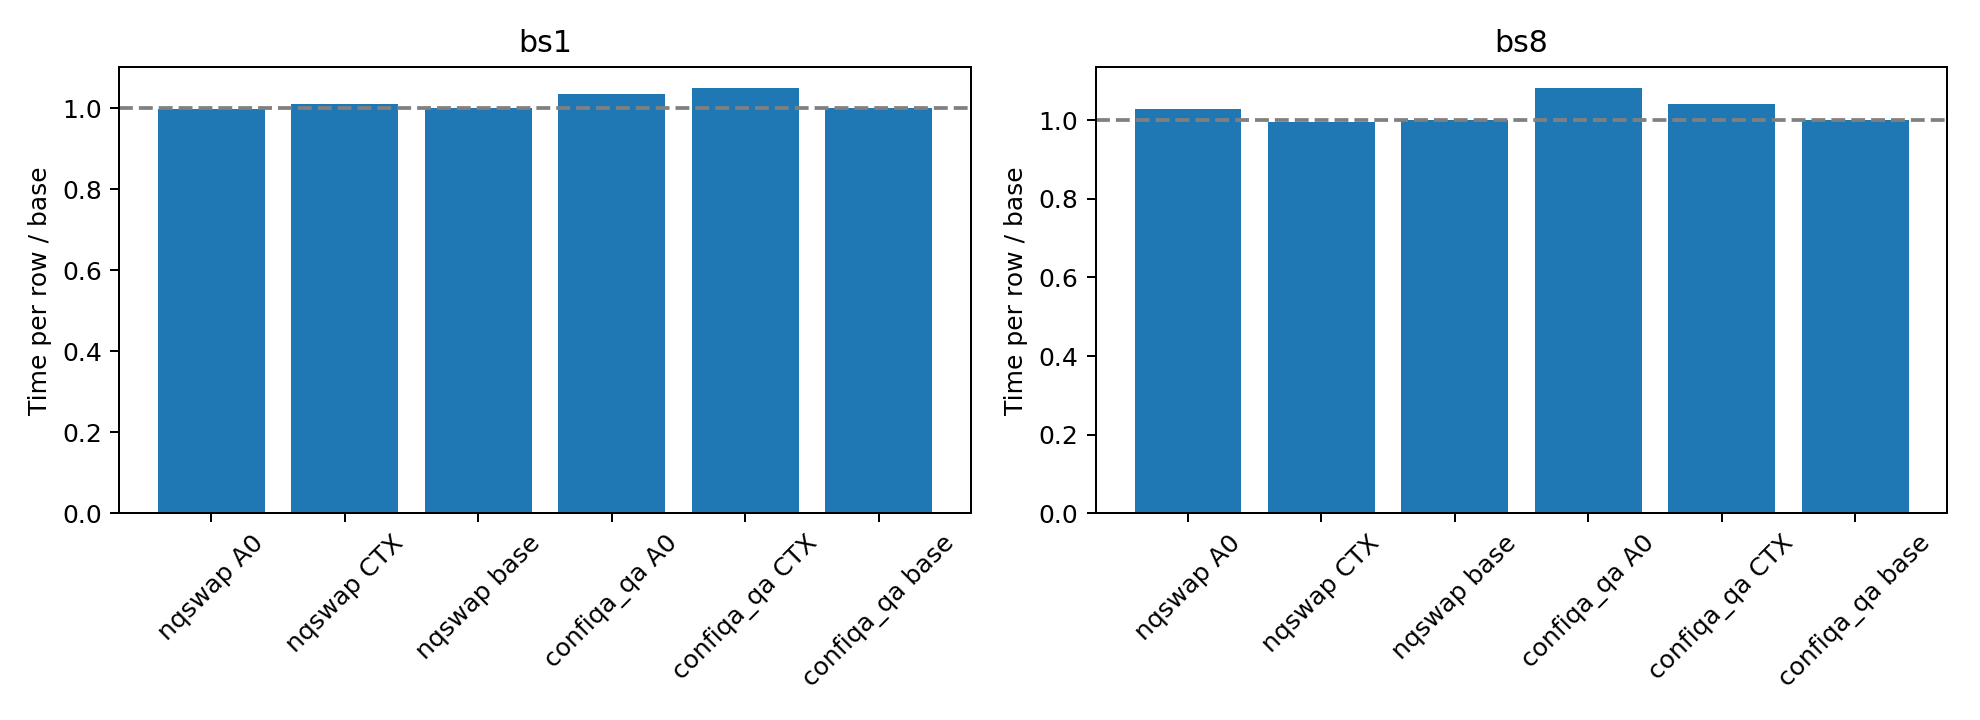

In [8]:
from IPython.display import display, Image
import pandas as pd, json
print('실행 폴더:', RUN)
print((RUN / 'status.json').read_text())
display(pd.read_csv(RUN / 'metrics.csv'))
display(pd.read_csv(RUN / 'comparisons.csv'))
print((RUN / 'verdict.json').read_text())
if (RUN / 'timing_summary.csv').is_file():
    display(pd.read_csv(RUN / 'timing_summary.csv'))
for filename in sorted(RUN.glob('*.png')):
    print(filename.name)
    display(Image(filename=str(filename)))


## 해석 시 주의

- 가장 좋은 arm/데이터/지표를 사후 선택해 성공으로 바꾸지 않습니다. 새 외부 결과를 보고 튜닝하면 해당 데이터는 개발셋이 됩니다.
- NQ-Swap과 ConFiQA-QA 점수는 **우리의 사실 정답 유지 목표로 재채점한 결과**입니다. 원 논문의 context-faithfulness leaderboard를 능가했다는 뜻이 아닙니다.
- K는 새 closed-book 생성의 strict EM입니다. 이전 relaxed K와 분모가 달라질 수 있습니다.
- 방향 생성과 K 분석에 사용한 별도 forward는 평가/준비 비용입니다. always-steering의 답변 생성에서는 C/K 라벨이나 CB 답을 읽지 않습니다.
- CTX의 시스템 지시문 차이, 데이터셋 gold/별칭 오류, 의미적 중복·사전학습 중복의 한계가 남습니다.
- 타이밍은 각 외부 데이터의 고정 표본 최대 64행에서 3회 측정합니다. 출력 길이가 달라지므로 순수 hook 오버헤드로 해석하지 않습니다.
- 의미상 정답 감사는 raw 출력과 gold를 보고 모든 방법에 동일한 기준으로 수행해야 합니다. 이 노트북은 LLM judge를 자동 호출하지 않습니다.
